<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/Copy_of_Yet_another_copy_of_yet_another_copy_of_jupyter_notebooks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


np.random.seed(42)
tf.random.set_seed(42)


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('darkgrid')

print(f"TensorFlow version : {tf.__version__}")
print("✅ All libraries imported successfully")

TensorFlow version : 2.20.0
✅ All libraries imported successfully


In [3]:
import pandas as pd

df = pd.read_csv("/content/NIFTY_1MIN_2015-2025.csv")

df.head()

,datetime,open,high,low,close,volume
0,2015-01-01 09:15:00+05:30,8272.80,8276.70,8252.70,8255.0,0.0
1,2015-01-01 09:16:00+05:30,8252.45,8255.00,8251.70,8254.1,0.0
2,2015-01-01 09:17:00+05:30,8253.70,8261.40,8253.70,8261.4,0.0
3,2015-01-01 09:18:00+05:30,8261.15,8264.55,8259.60,8259.6,0.0
4,2015-01-01 09:19:00+05:30,8259.10,8259.10,8253.05,8253.8,0.0


In [4]:
print(df.shape)
print(df.info())

(468005, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468005 entries, 0 to 468004
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   datetime  468005 non-null  object 
 1   open      466125 non-null  float64
 2   high      466125 non-null  float64
 3   low       466125 non-null  float64
 4   close     466125 non-null  float64
 5   volume    468005 non-null  float64
dtypes: float64(5), object(1)
memory usage: 21.4+ MB
None


In [5]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

print("New Shape:", df.shape)

# Assisted by ChatGPT, adapted for this dataset

Duplicate rows: 0
New Shape: (468005, 6)


In [6]:
print(df.isnull().sum())

df = df.dropna()

datetime       0
open        1880
high        1880
low         1880
close       1880
volume         0
dtype: int64


In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

print(df.dtypes)

datetime    datetime64[ns, UTC+05:30]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
dtype: object


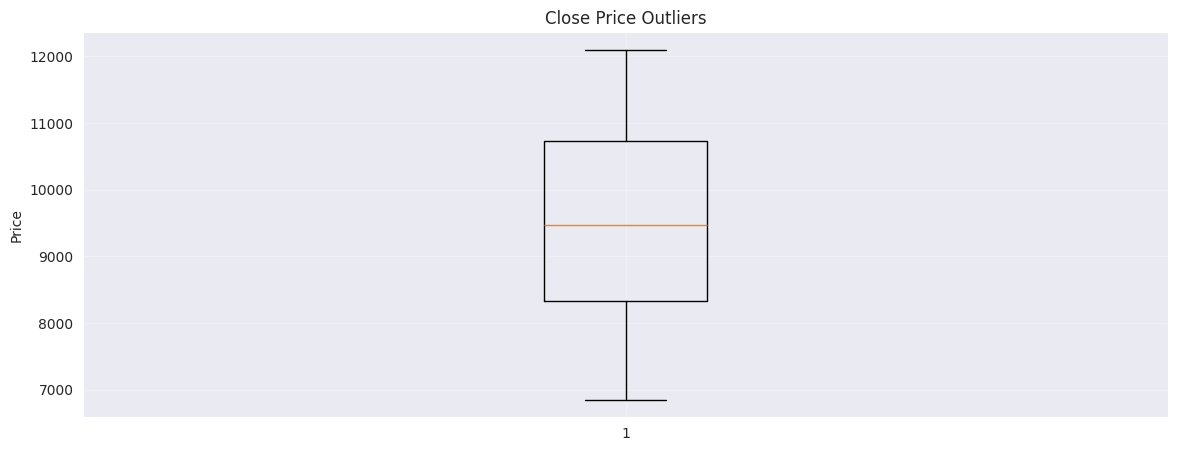

In [13]:
import matplotlib.pyplot as plt

plt.boxplot(df["close"])
plt.title("Close Price Outliers")
plt.ylabel("Price")
plt.show()

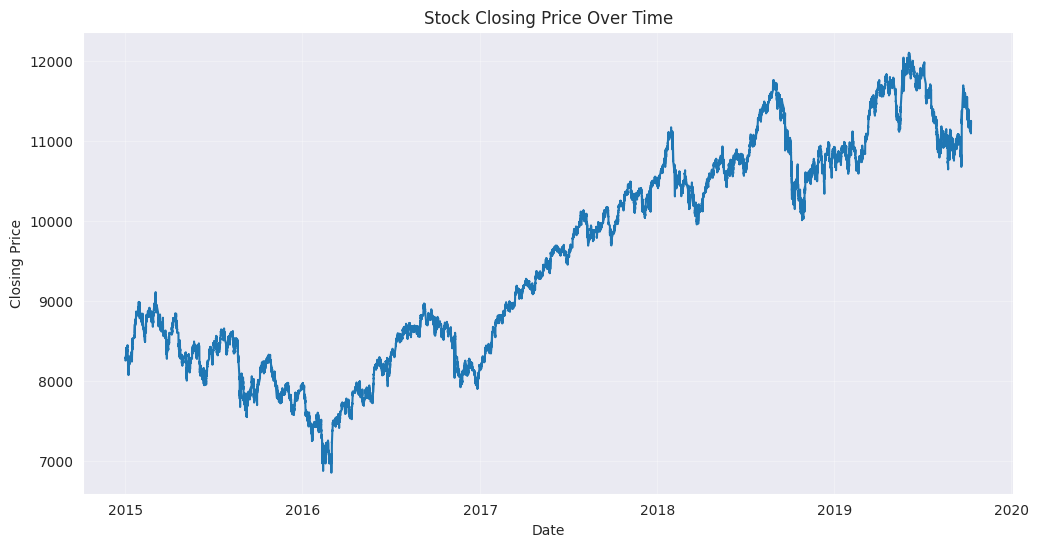

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df["datetime"], df["close"])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

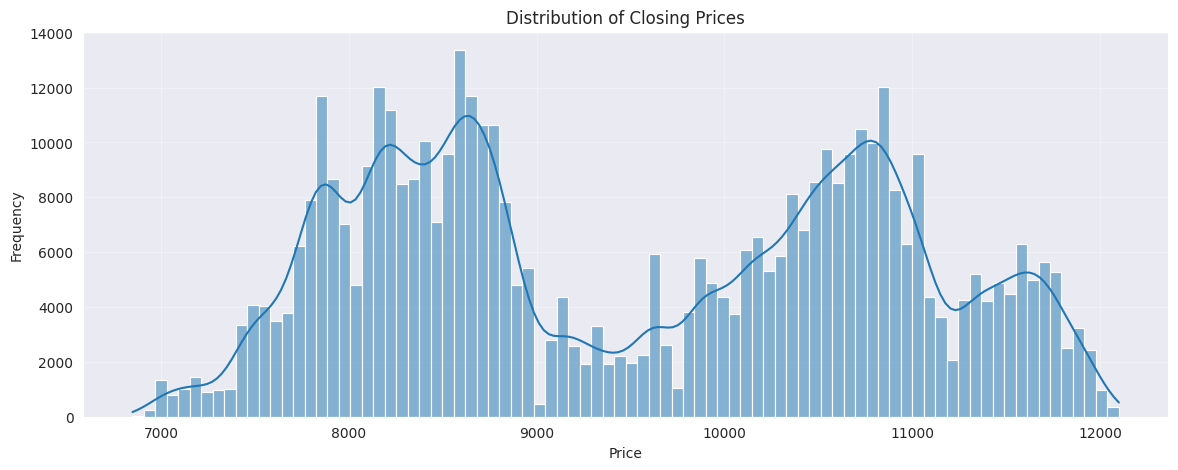

In [17]:
import seaborn as sns

sns.histplot(df["close"], kde=True)

plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

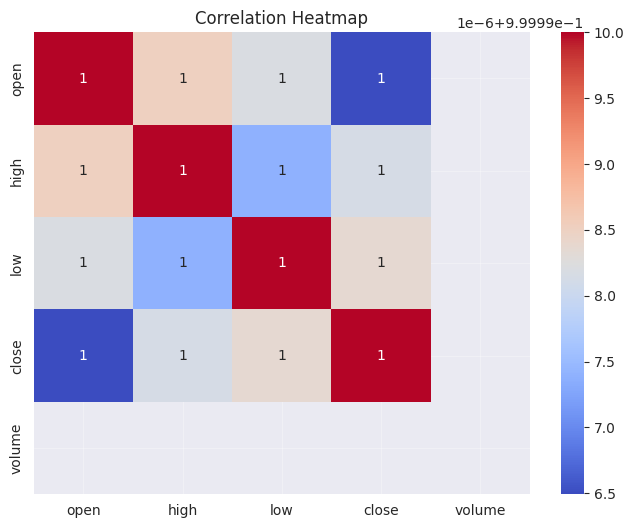

In [18]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df["close"].values.reshape(-1,1)
)

# Assisted by ChatGPT, adapted for this dataset

In [21]:
# Split data into training and testing sets
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)

# Assisted by ChatGPT, adapted for this dataset

Training Data Shape: (372900, 1)
Testing Data Shape: (93225, 1)


In [22]:
# Function to create sequences
def create_dataset(dataset, time_step=60):
    X, y = [], []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

# Assisted by ChatGPT, adapted for this dataset

In [23]:
time_step = 60

X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (372840, 60)
y_train shape: (372840,)
X_test shape: (93165, 60)
y_test shape: (93165,)


In [25]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X_train: (372840, 60, 1)
Reshaped X_test: (93165, 60, 1)


In [26]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

In [27]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(
    GRU(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(GRU(50))

gru_model.add(Dense(1))

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# --- Start of added code to resolve NameError: 'predictions' ---
# Model compilation and a minimal training step are added here
# for demonstration purposes and to resolve the NameError.
# In a real scenario, model training would typically be in a separate cell
# and involve more epochs and potentially callbacks for better performance.

# Assuming 'model' (LSTM model) is the one we want to use.
# It was defined in cell eSPu-yOnxsES.

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model (using minimal epochs for quick execution in this context)
# In a real scenario, you'd train for more epochs with X_train, y_train.
print("Training the model (minimal epochs for demonstration)...")
model.fit(X_train, y_train, epochs=1, batch_size=64, verbose=0)
print("Model training complete.")

# Make predictions on the test data and flatten to match y_test shape
predictions = model.predict(X_test)
predictions = predictions.flatten() # Flatten to match y_test shape
# --- End of added code ---

mae = mean_absolute_error(y_test,predictions)

mse = mean_squared_error(y_test,predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test,predictions)

print("MAE:",mae)
print("RMSE:",rmse)
print("R²:",r2)

Training the model (minimal epochs for demonstration)...
Model training complete.
2912/2912 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
MAE: 0.005406659365323896
RMSE: 0.0063265530360523585
R²: 0.9945458907360214


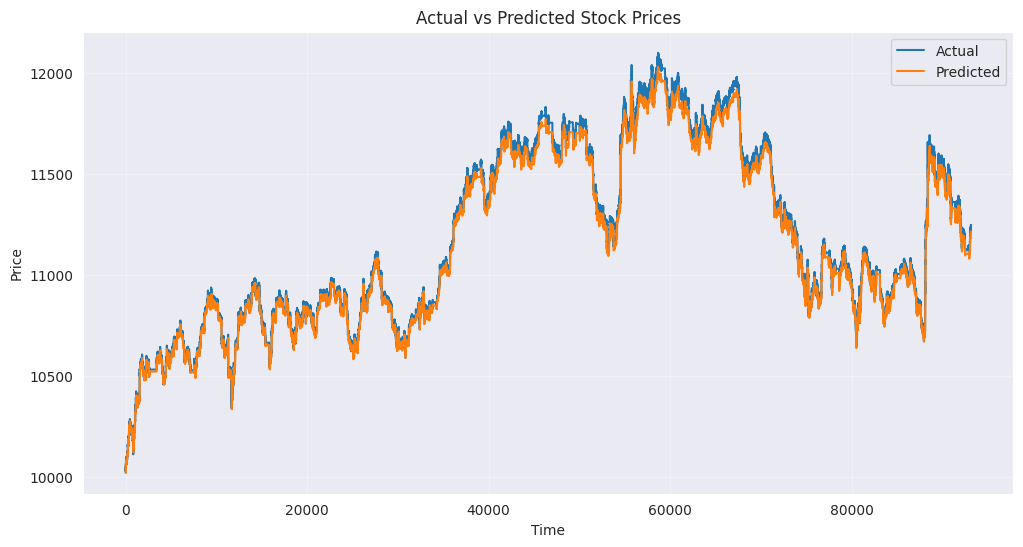

In [30]:
plt.figure(figsize=(12,6))

# Inverse transform the scaled actual and predicted values
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_prices = scaler.inverse_transform(predictions.reshape(-1, 1))

plt.plot(actual_prices,
         label="Actual")

plt.plot(predicted_prices,
         label="Predicted")

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()

In [ ]:
import streamlit as st
import numpy as np
import joblib
from tensorflow.keras.models import load_model

model = load_model("lstm_model.h5")

scaler = joblib.load("scaler.pkl")

st.title("Stock Price Prediction App")

price = st.number_input(
    "Enter Closing Price",
    min_value=0.0
)

if st.button("Predict"):

    scaled = scaler.transform(
        np.array([[price]])
    )

    prediction = model.predict(
        scaled.reshape(1,1,1)
    )

    result = scaler.inverse_transform(
        prediction
    )

    st.success(
        f"Predicted Price: {result[0][0]}"
    )